In [13]:
#CELL 1: Import Library & Konfigurasi

# %% [markdown]
# # Thesis Project: Energy Consumption Forecasting
# ## Comparative Study: XGBoost vs LSTM (Deep Learning)
# **Author:** [Nama Anda]

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import glob
import os

# Konfigurasi Plot
plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print(">>> Libraries Imported Successfully.")

>>> Libraries Imported Successfully.


In [14]:
#CELL 2: Data Ingestion (Memuat Data Mentah)

print(">>> [PHASE 1] Loading Raw Data...")

# List file manual sesuai urutan upload
files = [
    'data_2024_part1.csv', 'data_2024_part2.csv', 'data_2024_part3.csv',
    'data_2024_part4.csv', 'data_2024_part5.csv', 'data_2024_part6.csv'
]

df_list = []
# Kolom yang wajib ada
cols_needed = ['id_time', 'id_meter_id', 'id_stand_energy_kirim']

for f in files:
    if os.path.exists(f):
        print(f"Reading {f}...")
        try:
            temp = pd.read_csv(f, usecols=cols_needed)
            df_list.append(temp)
        except Exception as e:
            print(f"Error reading {f}: {e}")
    else:
        print(f"WARNING: File {f} not found!")

# Gabungkan
df_raw = pd.concat(df_list, ignore_index=True)
df_raw['id_time'] = pd.to_datetime(df_raw['id_time'])

# Sort WAJIB dilakukan sebelum perhitungan diff
df_raw = df_raw.sort_values(by=['id_meter_id', 'id_time'])

print(f"Total Raw Rows: {len(df_raw)}")
print(df_raw.head())

>>> [PHASE 1] Loading Raw Data...
Reading data_2024_part1.csv...
Reading data_2024_part2.csv...
Reading data_2024_part3.csv...
Reading data_2024_part4.csv...
Reading data_2024_part5.csv...
Reading data_2024_part6.csv...
Total Raw Rows: 2508187
                id_time  id_meter_id  id_stand_energy_kirim
25  2024-01-01 00:04:20            0           715957000.00
50  2024-01-01 00:11:20            0           715966000.00
54  2024-01-01 00:19:20            0           715996000.00
103 2024-01-01 00:37:20            0           716044000.00
128 2024-01-01 00:48:20            0           716074000.00


In [15]:
# %%
print(">>> [PHASE 1.5] Mapping & Filtering Meter ID (Contextualization)...")

# 1. Buat Dictionary Mapping (Salin SEMUA ID dari gambar anda ke sini)
# Saya masukkan beberapa contoh dari gambar, ANDA HARUS MELENGKAPINYA SAMPAI BAWAH.
meter_mapping = {
#OPMC

    #SDP
    251400282: "OPMC_SDP_Lt1",
    251400249: "OPMC_SDP_Lt2",
    251400248: "OPMC_SDP_Lt3",
    251400319: "OPMC_SDP_Lt4",
    251400323: "OPMC_SDP_Lt5",
    251400386: "OPMC_SDP_Lt6",

    #AH_
    251400247: "OPMC_AHU_Lt2",
    251400318: "OPMC_AHU_Lt3",
    251400244: "OPMC_AHU_Lt4",
    251400281: "OPMC_AHU_Lt5",
    251400270: "OPMC_AHU_Lt6",

    #LIFT
    251400378: "OPMC_LIFT",

#WITEL

    #SDP
    251400383: "WITEL_SDP_Lt1",
    251400322: "WITEL_SDP_Lt2",
    251400320: "WITEL_SDP_Lt3",
    251400277: "WITEL_SDP_Lt4",
    251400381: "WITEL_SDP_Lt5",
    251400384: "WITEL_SDP_Lt6",
    251400279: "WITEL_SDP_Lt7",
    251400278: "WITEL_SDP_Lt8",

    #AHU
    251400251: "WITEL_AHU_Lt1",
    251400321: "WITEL_AHU_Lt2",
    251400387: "WITEL_AHU_Lt3",
    251400373: "WITEL_AHU_Lt4",
    251400316: "WITEL_AHU_Lt5",
    251400276: "WITEL_AHU_Lt6",
    251400382: "WITEL_AHU_Lt7",
    251400385: "WITEL_AHU_Lt8",

    #LIFT
    251400184: "WITEL_LIFT",

    #CHILLER
    251400177: "WITEL_CHILLER",
    # ... LANJUTKAN SENDIRI SESUAI GAMBAR ...
    # Pastikan semua ID di gambar masuk ke sini.
}

# 2. Terapkan Mapping ke Dataframe
# Buat kolom baru 'location_name'
df_raw['location_name'] = df_raw['id_meter_id'].map(meter_mapping)

# 3. FILTERING: Buang yang tidak ada di list (Unknown)
# Jika ID tidak ada di dictionary, dia akan jadi NaN (Not a Number). Kita buang NaN.
print(f"Total Baris Sebelum Filter Lokasi: {len(df_raw)}")

df_known = df_raw.dropna(subset=['location_name']).copy()

print(f"Total Baris Setelah Filter (Hanya Lokasi Terdaftar): {len(df_known)}")
print(f"Data Dibuang (Unknown/Irrelevan): {len(df_raw) - len(df_known)}")

# Tampilkan sebaran data per lokasi (Bagus untuk Bab 4)
print("\n=== DISTRIBUSI DATA PER LOKASI ===")
print(df_known['location_name'].value_counts())

# Ganti df_raw dengan df_known untuk proses selanjutnya
df_raw = df_known

>>> [PHASE 1.5] Mapping & Filtering Meter ID (Contextualization)...
Total Baris Sebelum Filter Lokasi: 2508187
Total Baris Setelah Filter (Hanya Lokasi Terdaftar): 1937437
Data Dibuang (Unknown/Irrelevan): 570750

=== DISTRIBUSI DATA PER LOKASI ===
location_name
OPMC_SDP_Lt1     117408
OPMC_AHU_Lt4      73967
WITEL_AHU_Lt5     72520
OPMC_LIFT         72430
OPMC_AHU_Lt5      72045
OPMC_SDP_Lt4      71438
WITEL_AHU_Lt4     70742
WITEL_AHU_Lt2     70297
OPMC_AHU_Lt6      69783
WITEL_AHU_Lt3     68182
WITEL_SDP_Lt4     67999
OPMC_SDP_Lt6      67747
OPMC_AHU_Lt2      67648
OPMC_SDP_Lt3      67227
OPMC_SDP_Lt5      65613
OPMC_AHU_Lt3      64377
WITEL_SDP_Lt1     64291
WITEL_AHU_Lt6     63456
WITEL_AHU_Lt8     62702
OPMC_SDP_Lt2      62179
WITEL_SDP_Lt3     62143
WITEL_AHU_Lt1     61895
WITEL_SDP_Lt5     59817
WITEL_LIFT        59092
WITEL_SDP_Lt8     57422
WITEL_AHU_Lt7     57281
WITEL_SDP_Lt6     56183
WITEL_SDP_Lt2     53211
WITEL_SDP_Lt7     51396
WITEL_CHILLER      6946
Name: count, dtyp

In [16]:
#CELL 3: Data Cleaning & Outlier Removal (Audit)

print(">>> [PHASE 2] Cleaning & Anomaly Detection...")

# 1. Hitung Selisih (Energy Consumption)
df_raw['energy_consumed'] = df_raw.groupby('id_meter_id')['id_stand_energy_kirim'].diff()

# 2. Hapus Baris Pertama (NaN) dan Nilai Negatif (Reset Meter)
df_clean = df_raw.dropna(subset=['energy_consumed'])
df_clean = df_clean[df_clean['energy_consumed'] >= 0]

# 3. AUDIT SEBELUM OUTLIER REMOVAL
print("\n--- STATISTIK SEBELUM CLEANING ---")
print(df_clean['energy_consumed'].describe())

# 4. Outlier Removal (99th Percentile Rule)
# Membuang 1% data teratas yang tidak masuk akal (contoh: 267 Juta Wh)
upper_limit = df_clean['energy_consumed'].quantile(0.99)
print(f"\n>>> Threshold Outlier (Batas Atas): {upper_limit:,.2f} Wh")

df_final_clean = df_clean[df_clean['energy_consumed'] <= upper_limit].copy()

print("\n--- STATISTIK SESUDAH CLEANING ---")
print(df_final_clean['energy_consumed'].describe())
print(f"Jumlah Data Dibuang: {len(df_clean) - len(df_final_clean)} baris")

>>> [PHASE 2] Cleaning & Anomaly Detection...

--- STATISTIK SEBELUM CLEANING ---
count    1937407.00
mean        2006.95
std        32489.37
min            0.00
25%            0.00
50%            0.00
75%          900.00
max     13110000.00
Name: energy_consumed, dtype: float64

>>> Threshold Outlier (Batas Atas): 17,000.00 Wh

--- STATISTIK SESUDAH CLEANING ---
count   1918689.00
mean       1093.38
std        2450.35
min           0.00
25%           0.00
50%           0.00
75%         700.00
max       17000.00
Name: energy_consumed, dtype: float64
Jumlah Data Dibuang: 18718 baris


In [17]:
#CELL 4: Resampling & Merging Weather

# %%
print(">>> [PHASE 3] Resampling & Merging Weather...")

# 1. Resample ke Per Jam (Total Gedung)
df_final_clean.set_index('id_time', inplace=True)
df_hourly = df_final_clean.resample('H')['energy_consumed'].sum().to_frame()

# 2. Load Cuaca
df_weather = pd.read_csv('data_cuaca_merged.csv')
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather.set_index('time', inplace=True)

# 3. Join (Inner Join)
dataset = df_hourly.join(df_weather, how='inner')

# 4. Handle Missing Values (jika ada bolong saat join)
dataset.fillna(method='ffill', inplace=True)

# 5. Feature Engineering
dataset['hour'] = dataset.index.hour
dataset['day_of_week'] = dataset.index.dayofweek
dataset['lag_1h'] = dataset['energy_consumed'].shift(1)
dataset['lag_24h'] = dataset['energy_consumed'].shift(24)

# Hapus baris kosong akibat Lagging
dataset.dropna(inplace=True)

print(f"Final Dataset Shape: {dataset.shape}")
dataset.head()

>>> [PHASE 3] Resampling & Merging Weather...


C:\Users\Admin\AppData\Local\Temp\ipykernel_10888\4072353339.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_final_clean.resample('H')['energy_consumed'].sum().to_frame()


Final Dataset Shape: (8760, 25)


C:\Users\Admin\AppData\Local\Temp\ipykernel_10888\4072353339.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dataset.fillna(method='ffill', inplace=True)


,energy_consumed,relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),precipitation (mm),pressure_msl (hPa),surface_pressure (hPa),evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),...,uv_index (),direct_radiation (W/m²),temperature_2m (°C),showers (mm),cloud_cover (%),weather_description,hour,day_of_week,lag_1h,lag_24h
id_time,,,,,,,,,,,,,,,,,,,,,
2024-01-02 00:00:00,221800.00,89,24.30,32.30,0.50,1009.80,1006.90,0.02,0.37,1.10,...,0.00,0.00,26.20,0.50,100,Rain showers: Slight,0,1,214800.00,151740.00
2024-01-02 01:00:00,241600.00,88,24.10,32.10,0.00,1009.50,1006.60,0.01,0.41,1.90,...,0.00,0.00,26.30,0.00,100,Overcast,1,1,221800.00,204700.00
2024-01-02 02:00:00,222300.00,89,24.10,31.90,0.00,1008.60,1005.70,0.02,0.37,1.50,...,0.00,0.00,26.00,0.00,100,Overcast,2,1,241600.00,197400.00
2024-01-02 03:00:00,197400.00,90,24.10,31.90,0.00,1008.50,1005.60,0.01,0.33,1.30,...,0.00,0.00,25.90,0.00,100,Overcast,3,1,222300.00,157640.00
2024-01-02 04:00:00,169100.00,91,24.20,32.10,0.00,1008.50,1005.60,0.01,0.30,0.00,...,0.00,0.00,25.80,0.00,100,Overcast,4,1,197400.00,199960.00


>>> [PHASE 4] Quick EDA...


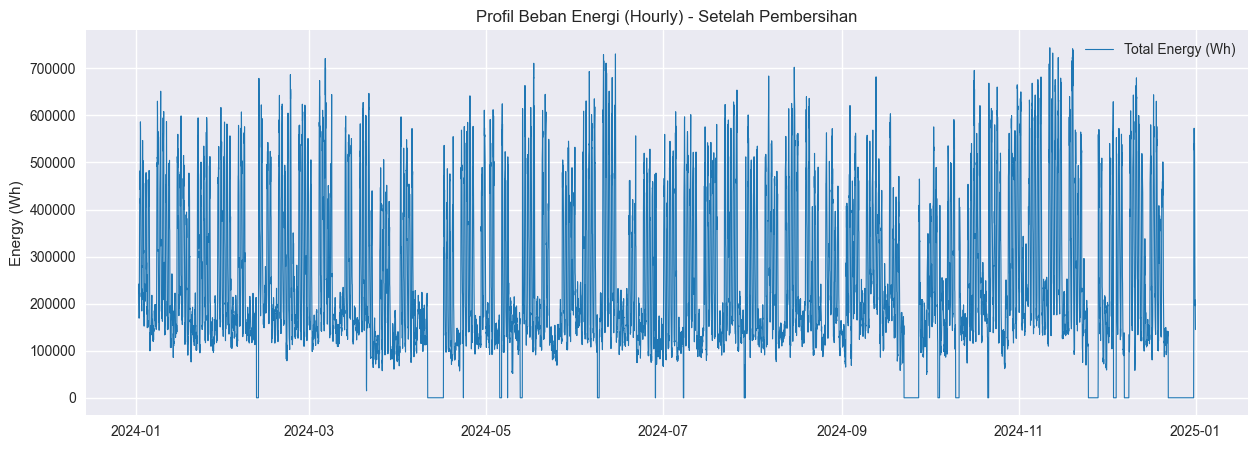

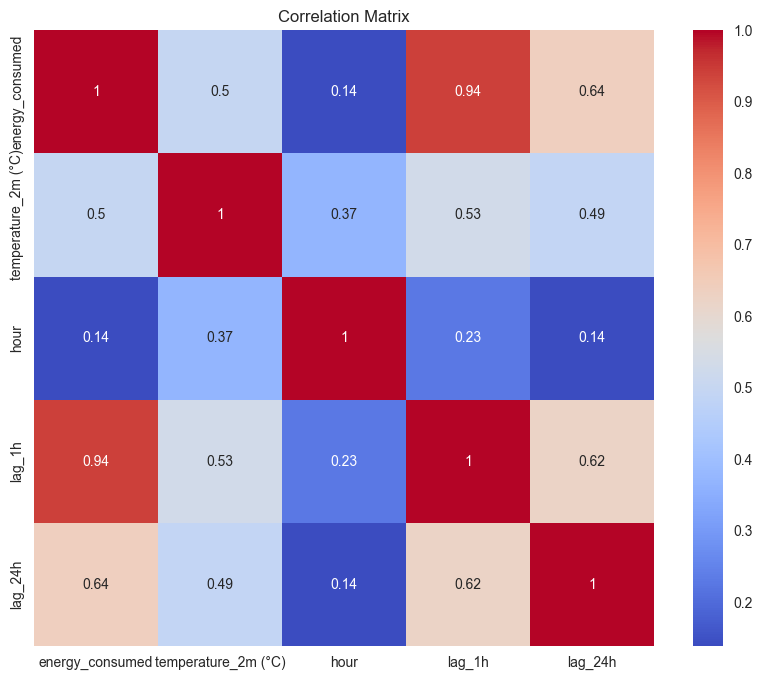

In [18]:
#CELL 5: EDA Singkat (Visualisasi Data Bersih)

# %%
print(">>> [PHASE 4] Quick EDA...")

plt.figure(figsize=(15, 5))
plt.plot(dataset.index, dataset['energy_consumed'], label='Total Energy (Wh)', color='tab:blue', linewidth=0.8)
plt.title('Profil Beban Energi (Hourly) - Setelah Pembersihan')
plt.ylabel('Energy (Wh)')
plt.legend()
plt.show()

# Korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(dataset[['energy_consumed', 'temperature_2m (°C)', 'hour', 'lag_1h', 'lag_24h']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

>>> [PHASE 5] Modeling: XGBoost (Benchmark)...
[0]	validation_0-rmse:153094.24771	validation_1-rmse:192615.15142
[100]	validation_0-rmse:36755.55699	validation_1-rmse:46211.46521
[150]	validation_0-rmse:35237.71914	validation_1-rmse:46444.68594

=== HASIL XGBOOST ===
RMSE: 46,210.73
MAE : 28,064.49


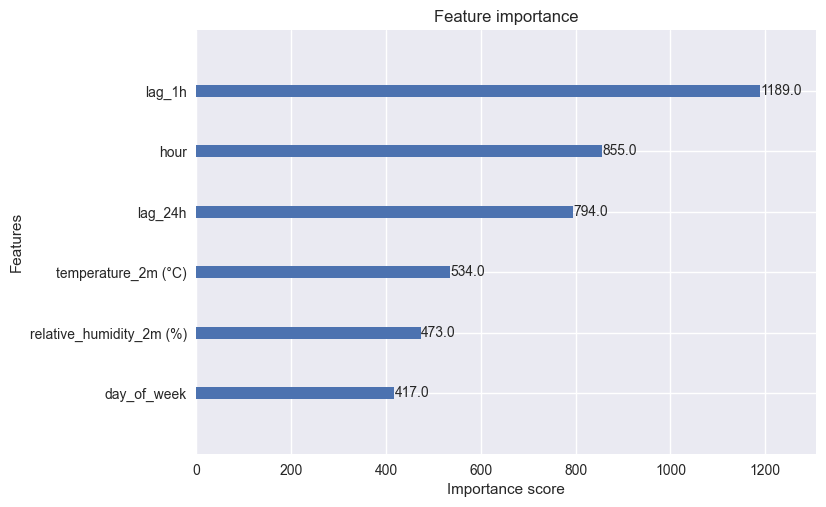

In [19]:
#CELL 6: Model 1 - XGBoost (Benchmark)

# %%
print(">>> [PHASE 5] Modeling: XGBoost (Benchmark)...")

# Split Data (Cutoff November)
split_date = '2024-11-01'
train = dataset[dataset.index < split_date]
test = dataset[dataset.index >= split_date]

# Define Features & Target
feature_cols = ['hour', 'day_of_week', 'lag_1h', 'lag_24h', 'temperature_2m (°C)', 'relative_humidity_2m (%)']
target_col = 'energy_consumed'

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print(f"\n=== HASIL XGBOOST ===")
print(f"RMSE: {xgb_rmse:,.2f}")
print(f"MAE : {xgb_mae:,.2f}")

# Plot Feature Importance
xgb.plot_importance(xgb_model, max_num_features=10)
plt.show()

In [20]:
#CELL 7: Model 2 - LSTM (Deep Learning) Setup

# %%
print(">>> [PHASE 6] Modeling: LSTM (Deep Learning)...")

# 1. Scaling (Wajib 0-1 untuk LSTM)
# Kita pakai fitur yang sama dengan XGBoost tapi ditambah target di kolom pertama
lstm_cols = ['energy_consumed'] + feature_cols 
data_values = dataset[lstm_cols].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_values)

# 2. Sliding Window Function
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), :]) # Ambil semua fitur
        y.append(data[i + seq_length, 0])     # Ambil target (kolom 0)
    return np.array(X), np.array(y)

SEQ_LENGTH = 24 # Lookback 24 jam
X_lstm, y_lstm = create_sequences(data_scaled, SEQ_LENGTH)

# 3. Split Train/Test (Index based)
# Kita harus hitung index potong manual berdasarkan rasio data train XGBoost
train_len = len(train) - SEQ_LENGTH # Adjust karena sequence
X_train_lstm = X_lstm[:train_len]
y_train_lstm = y_lstm[:train_len]
X_test_lstm = X_lstm[train_len:]
y_test_lstm = y_lstm[train_len:]

print(f"LSTM Input Shape: {X_train_lstm.shape} (Samples, Time Steps, Features)")

>>> [PHASE 6] Modeling: LSTM (Deep Learning)...
LSTM Input Shape: (7272, 24, 7) (Samples, Time Steps, Features)


In [21]:
#CELL 8: LSTM Training & Evaluation

# %%
# 4. Build Model
model = Sequential()
model.add(LSTM(units=64, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 5. Train
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1,
    shuffle=False # PENTING: Jangan di-shuffle untuk time series
)

# 6. Predict
lstm_pred_scaled = model.predict(X_test_lstm)

# 7. Inverse Transform (Mengembalikan ke nilai Asli Wh)
# Kita buat array dummy agar shape-nya cocok dengan scaler
dummy_test = np.zeros((len(lstm_pred_scaled), data_scaled.shape[1]))
dummy_test[:, 0] = lstm_pred_scaled.flatten()
lstm_pred_final = scaler.inverse_transform(dummy_test)[:, 0]

# Ambil y_actual yang sesuai index
y_test_actual_lstm = dataset['energy_consumed'].iloc[train_len+SEQ_LENGTH:].values

# 8. Evaluate LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual_lstm, lstm_pred_final))
lstm_mae = mean_absolute_error(y_test_actual_lstm, lstm_pred_final)

print(f"\n=== HASIL LSTM ===")
print(f"RMSE: {lstm_rmse:,.2f}")
print(f"MAE : {lstm_mae:,.2f}")

Epoch 1/50


c:\Users\Admin\Downloads\skripsi\metopen1\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0202 - val_loss: 0.0129
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0100 - val_loss: 0.0089
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0082 - val_loss: 0.0077
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0075 - val_loss: 0.0069
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0067 - val_loss: 0.0062
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0064 - val_loss: 0.0057
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0059 - val_loss: 0.0052
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0056 - val_loss: 0.0049
Epoch 9/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0052 - val_loss: 0.0048
Epoch 10/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 11/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0049 - val_loss: 0.0044
Epoch 12/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.

>>> [PHASE 7] Final Comparison...


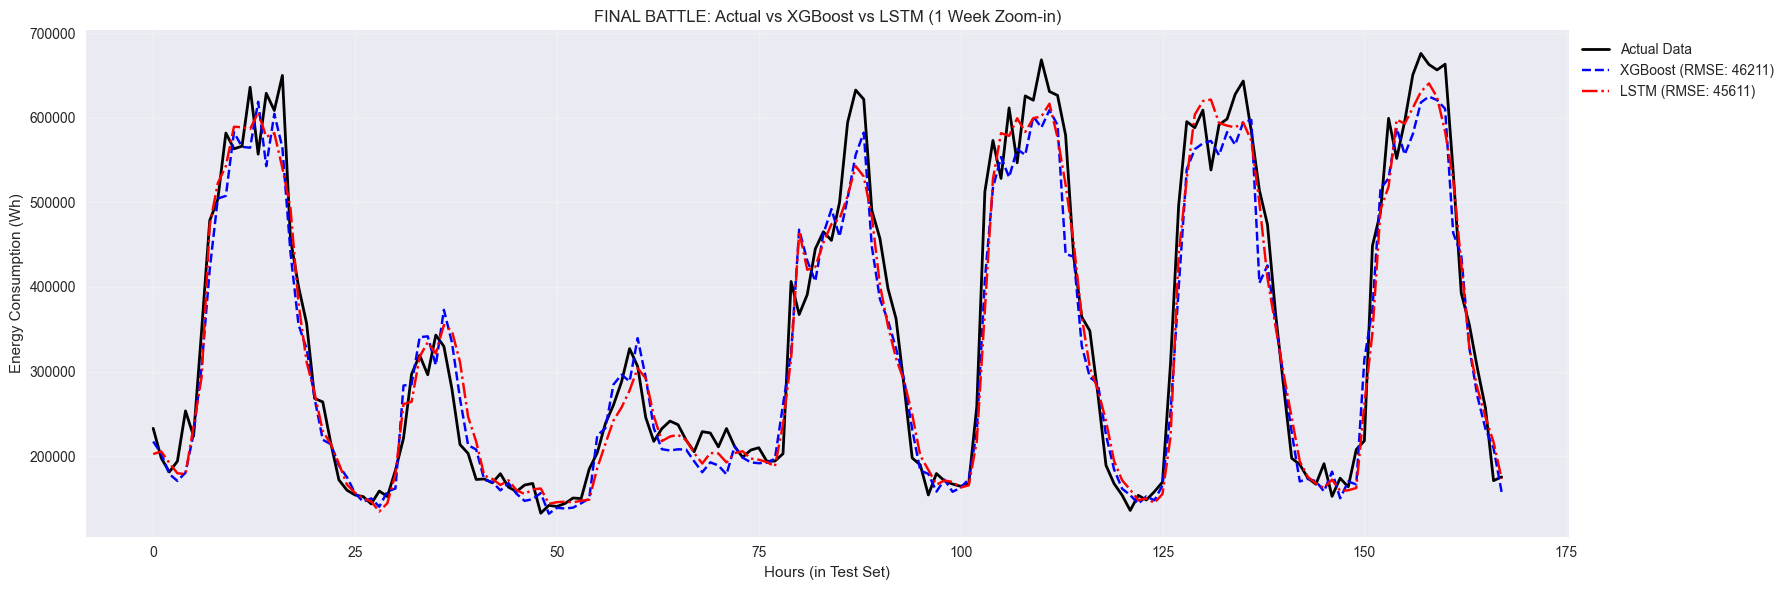

=== THESIS VERDICT ===
SUCCESS: LSTM outperforms XGBoost by reducing RMSE by 600 Wh!
Kesimpulan: Metode Deep Learning terbukti lebih akurat menangkap pola non-linear.


In [25]:
#CELL 9: Final Comparison Plot (Battle of Algorithms)

# %%
print(">>> [PHASE 7] Final Comparison...")

# Plot 1 Minggu Pertama Data Test
subset = 168 # 24 jam * 7 hari
start_idx = 0

plt.figure(figsize=(18, 6))
# Actual Data
plt.plot(range(subset), y_test_actual_lstm[start_idx:start_idx+subset], 
         label='Actual Data', color='black', linewidth=2)

# XGBoost Prediction (Perlu slice agar panjangnya sama dengan LSTM test set)
xgb_pred_aligned = xgb_pred[-len(lstm_pred_final):]
plt.plot(range(subset), xgb_pred_aligned[start_idx:start_idx+subset], 
         label=f'XGBoost (RMSE: {xgb_rmse:.0f})', color='blue', linestyle='--')

# LSTM Prediction
plt.plot(range(subset), lstm_pred_final[start_idx:start_idx+subset], 
         label=f'LSTM (RMSE: {lstm_rmse:.0f})', color='red', linestyle='-.')

plt.title('FINAL BATTLE: Actual vs XGBoost vs LSTM (1 Week Zoom-in)')
plt.ylabel('Energy Consumption (Wh)')
plt.xlabel('Hours (in Test Set)')
# bbox_to_anchor=(x, y). (1, 1) adalah pojok kanan atas grafik.
# Kode ini menggeser legend sedikit keluar ke sebelah kanan.
plt.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')

# PENTING: Jika menggunakan opsi ini, Anda mungkin perlu menyesuaikan layout agar tidak terpotong saat disimpan/ditampilkan
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

# Conclusion Print
print("=== THESIS VERDICT ===")
if lstm_rmse < xgb_rmse:
    diff = xgb_rmse - lstm_rmse
    print(f"SUCCESS: LSTM outperforms XGBoost by reducing RMSE by {diff:.0f} Wh!")
    print("Kesimpulan: Metode Deep Learning terbukti lebih akurat menangkap pola non-linear.")
else:
    print("INSIGHT: XGBoost performs better or equal to LSTM.")
    print("Kesimpulan: Untuk karakteristik data ini, model Machine Learning yang lebih ringan sudah cukup.")

>>> [PHASE 8] Generating Final Evaluation Table...

TABEL PERBANDINGAN PERFORMA MODEL (UNTUK BAB 4)
                       Metric  XGBoost (Benchmark)  LSTM (Deep Learning)  Improvement (%)
RMSE (Root Mean Square Error)             46210.73              45610.89             1.30
    MAE (Mean Absolute Error)             28064.49              28615.34            -1.96


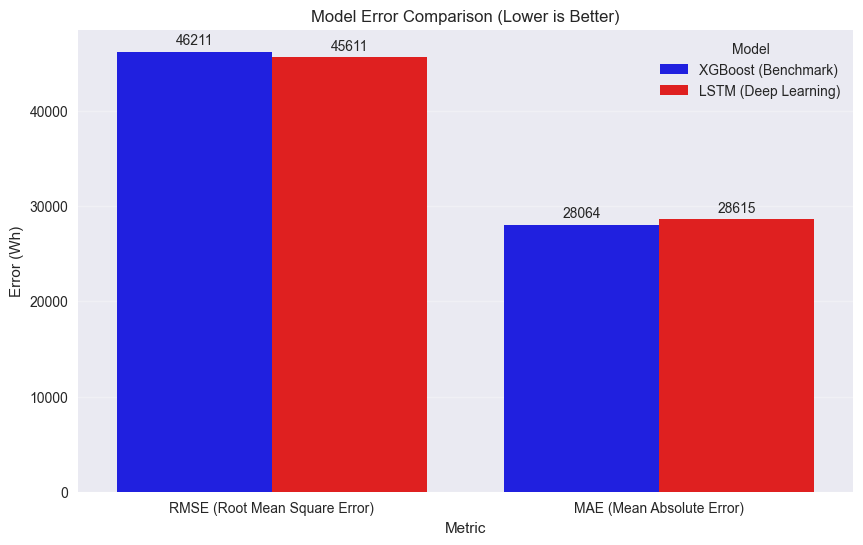

In [26]:
#CELL 10: Tabel Evaluasi Resmi (The Scorecard)

# %%
print(">>> [PHASE 8] Generating Final Evaluation Table...")

# 1. Buat Dataframe Perbandingan
results_data = {
    'Metric': ['RMSE (Root Mean Square Error)', 'MAE (Mean Absolute Error)'],
    'XGBoost (Benchmark)': [xgb_rmse, xgb_mae],
    'LSTM (Deep Learning)': [lstm_rmse, lstm_mae]
}

df_results = pd.DataFrame(results_data)

# 2. Hitung Improvement (Berapa % LSTM lebih baik?)
# Rumus: (XGB - LSTM) / XGB * 100
df_results['Improvement (%)'] = (
    (df_results['XGBoost (Benchmark)'] - df_results['LSTM (Deep Learning)']) 
    / df_results['XGBoost (Benchmark)'] * 100
)

# 3. Tampilkan Tabel Format Laporan
print("\n=======================================================")
print("TABEL PERBANDINGAN PERFORMA MODEL (UNTUK BAB 4)")
print("=======================================================")
print(df_results.to_string(index=False, float_format="%.2f"))
print("=======================================================")

# 4. Visualisasi Bar Chart untuk Tabel (Opsional tapi Bagus)
df_plot = df_results.melt(id_vars="Metric", value_vars=['XGBoost (Benchmark)', 'LSTM (Deep Learning)'], var_name="Model", value_name="Error Value")

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Error Value', hue='Model', palette=['blue', 'red'])
plt.title('Model Error Comparison (Lower is Better)')
plt.ylabel('Error (Wh)')
plt.grid(axis='y', alpha=0.3)
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', padding=3)
plt.show()